In [1]:
import time, gc
import numpy as np
import matplotlib.pyplot as plt

from LMM import LMM, EPS

%matplotlib inline

In [2]:
def ar1_correlation(p, rho):
    idx = np.arange(p)
    return rho ** np.abs(idx[:, None] - idx[None, :]).astype(float)


def generate_lmm_data(
    n, p,
    sigma_b2, sigma_e2,
    rng,
    q_cov=0, alpha_scale=1.0,
    x_ar1_rho=0.5,
):
    Z = rng.normal(size=(n, p))
    if abs(x_ar1_rho) > EPS:
        R = ar1_correlation(p, x_ar1_rho)
        X = Z @ np.linalg.cholesky(R).T
    else:
        X = Z

    X -= X.mean(axis=0)
    col_std = X.std(axis=0, ddof=1)
    X /= np.where(col_std < EPS, 1.0, col_std) * np.sqrt(p)

    beta_true = rng.normal(scale=np.sqrt(sigma_b2), size=p)
    eps = rng.normal(scale=np.sqrt(sigma_e2), size=n)

    if q_cov > 0:
        W_raw = rng.normal(size=(n, q_cov))
        W_raw -= W_raw.mean(axis=0)
        scale = np.sqrt(np.mean(W_raw**2, axis=0))
        W_raw /= np.where(scale < EPS, 1.0, scale)
        W = np.column_stack([np.ones(n), W_raw])
        alpha_true = rng.normal(scale=alpha_scale, size=q_cov + 1)
        y = W @ alpha_true + X @ beta_true + eps
    else:
        W = alpha_true = None
        y = X @ beta_true + eps
        y -= y.mean()

    return X, y, beta_true, W, alpha_true

In [3]:
P = 100
N_VALUES = [500, 1000, 2000, 5000]
N_REPS = 100
SIGMA_B2_TRUE = 0.5
SIGMA_E2_TRUE = 0.5
Q_COV = 10
X_AR1_RHO = 0.5
BASE_SEED = 42
TOL = 1e-4
MAX_ITER = 1500

METHODS = ["EM", "PX-EM", "MM", "CAVI"]
print(f"p={P}, n_values={N_VALUES}, reps={N_REPS}, x_ar1_rho={X_AR1_RHO}")

p=100, n_values=[500, 1000, 2000, 5000], reps=100, x_ar1_rho=0.5


In [4]:
def run_one_rep(n, p, rep_id, seed):
    rng = np.random.default_rng(seed)
    X, y, beta_true, W, alpha_true = generate_lmm_data(
        n, p,
        SIGMA_B2_TRUE, SIGMA_E2_TRUE,
        rng,
        q_cov=Q_COV,
        x_ar1_rho=X_AR1_RHO,
    )
    eta_true = X @ beta_true
    model = LMM(tol=TOL, max_iter=MAX_ITER)

    runners = {
        "EM": lambda: model.EM(X, y, W),
        "PX-EM": lambda: model.PX_EM(X, y, W),
        "MM": lambda: model.MM(X, y, W),
        "CAVI": lambda: model.CAVI(X, y, W),
    }

    metrics = {}
    for name in METHODS:
        t0 = time.perf_counter()
        try:
            res = runners[name]()
            elapsed = time.perf_counter() - t0
            eta_hat = X @ res["beta_hat"]
            mse_eta = float(np.mean((eta_hat - eta_true) ** 2))
            mse_beta = float(np.mean((res["beta_hat"] - beta_true) ** 2))
            var_q = res["beta_var"] if name == "CAVI" else None

            unc = LMM.posterior_uncertainty_diagnostics(
                X,
                res["beta_hat"],
                beta_true,
                res["sigma_b2"],
                res["sigma_e2"],
                var_q=var_q,
            )

            entry = {
                "sigma_b2": float(res["sigma_b2"]),
                "sigma_e2": float(res["sigma_e2"]),
                "mse_eta": mse_eta,
                "mse_beta": mse_beta,
                "runtime": elapsed,
                "var_ratio": unc["var_ratio"],
                "coverage_q": unc["coverage_q"],
            }
            if alpha_true is not None:
                entry["mse_alpha"] = float(np.mean((res["alpha_hat"] - alpha_true) ** 2))
            metrics[name] = entry
        except Exception as e:
            elapsed = time.perf_counter() - t0
            print(f"[WARN] {name} failed at n={n} rep={rep_id}: {e}")
            entry = {
                "sigma_b2": np.nan,
                "sigma_e2": np.nan,
                "mse_eta": np.nan,
                "mse_beta": np.nan,
                "runtime": elapsed,
                "var_ratio": np.nan,
                "coverage_q": np.nan,
            }
            if alpha_true is not None:
                entry["mse_alpha"] = np.nan
            metrics[name] = entry

    gc.collect()
    return metrics

## Run simulation

In [5]:
all_results = {}

for n in N_VALUES:
    print(f"n = {n:,}  (p = {P})")
    all_results[n] = {"methods": METHODS, "reps": []}

    for rep in range(N_REPS):
        seed = BASE_SEED + n + rep * 1000
        metrics = run_one_rep(n, P, rep, seed)
        all_results[n]["reps"].append(metrics)

n = 500  (p = 100)
n = 1,000  (p = 100)
n = 2,000  (p = 100)
n = 5,000  (p = 100)


In [6]:
agg = {}
for n in N_VALUES:
    reps = all_results[n]["reps"]
    agg[n] = {}
    for m in METHODS:
        entry = {
            "runtime": np.array([r[m]["runtime"] for r in reps]),
            "mse_eta": np.array([r[m]["mse_eta"] for r in reps]),
            "mse_beta": np.array([r[m]["mse_beta"] for r in reps]),
            "mse_alpha": np.array([r[m]["mse_alpha"] for r in reps]),
            "sigma_b2": np.array([r[m]["sigma_b2"] for r in reps]),
            "sigma_e2": np.array([r[m]["sigma_e2"] for r in reps]),
            "var_ratio": np.array([r[m]["var_ratio"] for r in reps]),
            "coverage_q": np.array([r[m]["coverage_q"] for r in reps]),
        }
        agg[n][m] = entry

## Save summary results


In [8]:
# SAVE_SUMMARY_RESULTS
from pathlib import Path
import pandas as pd

save_dir = Path("../../results/LMM")
save_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []
for n in N_VALUES:
    for method in METHODS:
        for metric, values in agg[n][method].items():
            finite = values[np.isfinite(values)]
            summary_rows.append({
                "n": n,
                "method": method,
                "metric": metric,
                "mean": np.nanmean(values),
                "std": np.nanstd(values, ddof=1),
                "median": np.nanmedian(values),
                "n_finite": len(finite),
            })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(save_dir / "summary.csv", index=False)

raw_rows = []
for n in N_VALUES:
    for rep_id, rep_metrics in enumerate(all_results[n]["reps"]):
        for method in METHODS:
            row = {"n": n, "rep": rep_id, "method": method}
            row.update(rep_metrics[method])
            raw_rows.append(row)
raw_df = pd.DataFrame(raw_rows)
raw_df.to_csv(save_dir / "raw_results.csv", index=False)

print(f"Saved LMM summary results to {save_dir}")


Saved LMM summary results to ../../results/LMM


## Boxplots: MSE and runtime across sample size

In [ ]:
import matplotlib.patches as mpatches

FIGSIZE = (11, 7.5)
AXIS_LABEL_SIZE = 20
TICK_LABEL_SIZE = 16
LEGEND_SIZE = 14
BOX_WIDTH = 0.17


def grouped_boxplot(metric_key, ylabel, log_y=False, log_transform=False, true_val=None):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    n_groups = len(N_VALUES)
    n_methods = len(METHODS)
    positions_base = np.arange(n_groups)
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    legend_handles = []
    for j, method in enumerate(METHODS):
        data_list = []
        pos_list = []
        for i, n in enumerate(N_VALUES):
            vals = agg[n][method][metric_key]
            vals = vals[~np.isnan(vals)]
            if log_transform:
                vals = vals[vals > 0]
                vals = np.log(vals)
            data_list.append(vals)
            pos_list.append(
                positions_base[i] + (j - (n_methods - 1) / 2) * BOX_WIDTH
            )

        color = colors[j % len(colors)]
        ax.boxplot(
            data_list,
            positions=pos_list,
            widths=BOX_WIDTH * 0.82,
            patch_artist=True,
            showmeans=True,
            showfliers=True,
            meanprops=dict(
                marker="D",
                markerfacecolor="white",
                markeredgecolor=color,
                markersize=6,
            ),
            medianprops=dict(color="white", linewidth=1.5),
            flierprops=dict(marker=".", markersize=4, alpha=0.4, markeredgecolor=color),
            boxprops=dict(facecolor=color, alpha=0.75, edgecolor=color),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
        )
        legend_handles.append(mpatches.Patch(color=color, alpha=0.75, label=method))

    if true_val is not None:
        ax.axhline(true_val, linestyle="--", color="black", alpha=0.6)

    ax.set_xticks(positions_base)
    ax.set_xticklabels([f"{n:,}" for n in N_VALUES])
    ax.set_xlabel(r"Sample size $n$", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)
    if log_y:
        ax.set_yscale("log")
    ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
    ax.legend(handles=legend_handles, loc="best", fontsize=LEGEND_SIZE)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

Compare the runtime across sample sizes.

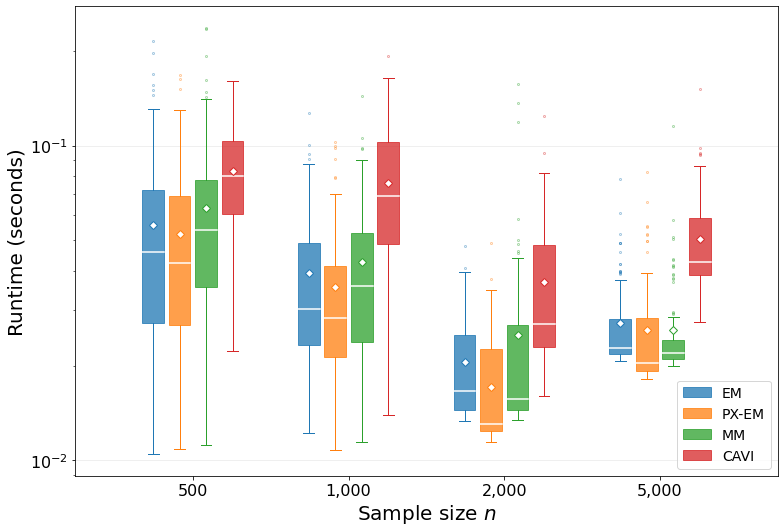

In [9]:
grouped_boxplot("runtime", "Runtime (seconds)", log_y=True)


### Random-effect coefficient error

This plot compares the log MSE of the estimated random-effect coefficients beta across sample sizes.


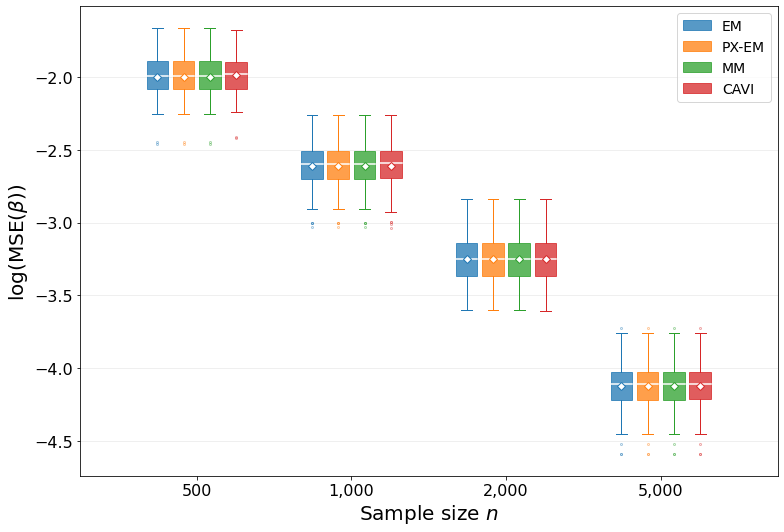

In [10]:
grouped_boxplot("mse_beta", r"$\log(\mathrm{MSE}(\beta))$", log_transform=True)


Compare the log MSE of the estimated fixed-effect coefficients alpha across sample sizes.


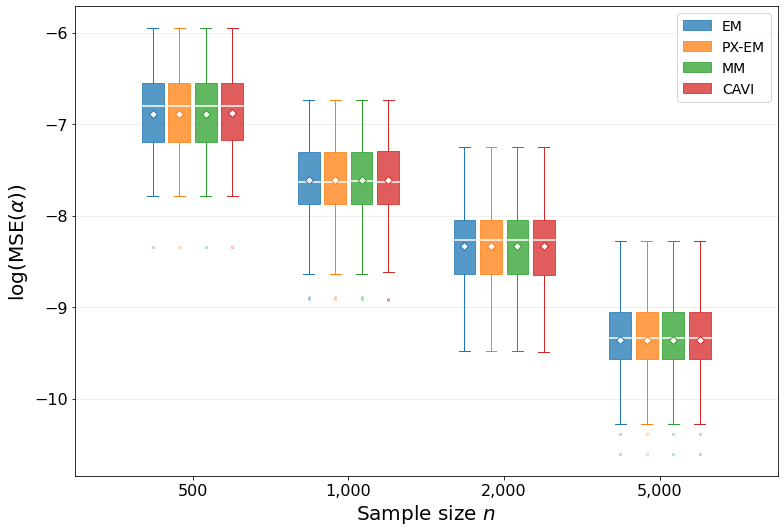

In [11]:
grouped_boxplot("mse_alpha", r"$\log(\mathrm{MSE}(\alpha))$", log_transform=True)




Mean-field CAVI uses diagonal variances $s_j^2 = 1/\Lambda_{jj}$, while the exact marginal posterior variances are $\Sigma_{jj} = (\Lambda^{-1})_{jj}$ with $\Lambda = X^\top X/\sigma_e^2 + I_p/\sigma_b^2$. We report
$$
\frac{1}{p}\sum_{j=1}^p \frac{s_j^2}{\Sigma_{jj}}
$$
(values below 1 indicate variance underestimation) and the fraction of coordinates covered by nominal 95% intervals $[\hat\beta_j \pm 1.96\sqrt{s_j^2}]$.


Check whether CAVI posterior variances are calibrated relative to the exact marginal posterior variances.


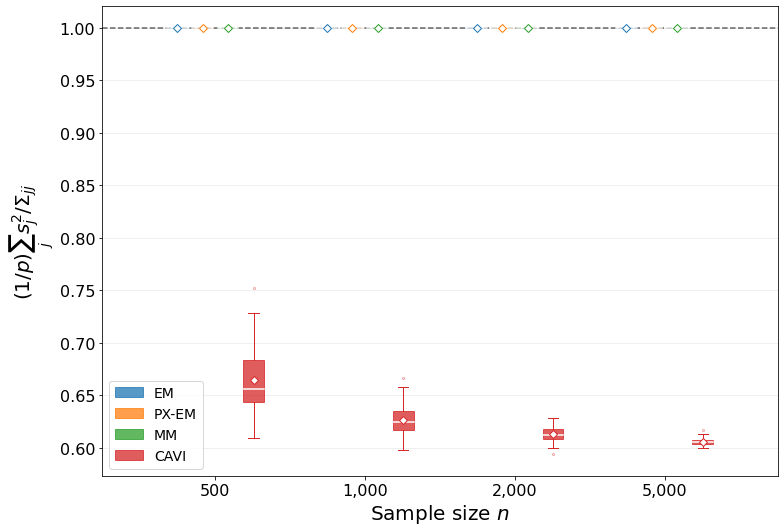

In [12]:
grouped_boxplot("var_ratio", r"$(1/p)\sum_j s_j^2 / \Sigma_{jj}$", true_val=1.0)


Report the empirical coverage of nominal 95% intervals for beta.


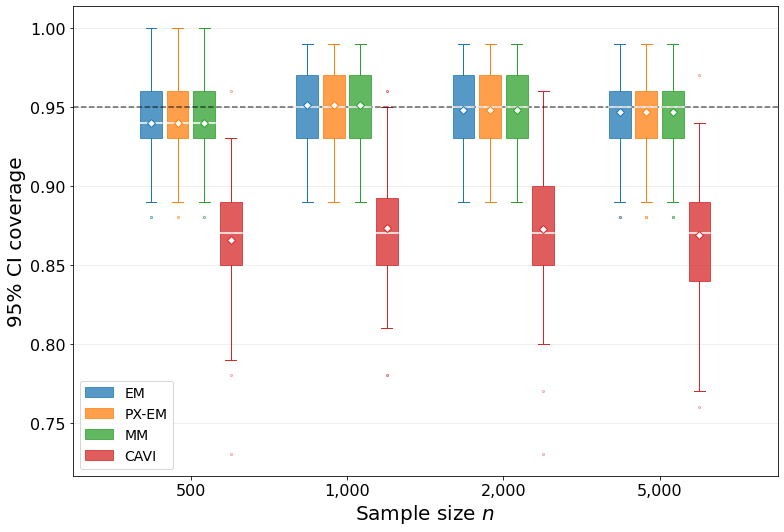

In [13]:
grouped_boxplot("coverage_q", "95% CI coverage", true_val=0.95)
